# NBT meaningful-overrun classification

**Question:** Will the operation exceed its planned duration by more than the working tolerance?

This notebook uses one cleaned analysis dataset and creates all experimental configurations in memory. It selects the missing-data approach, feature representation and algorithm using development cross-validation. The held-out test set is evaluated only after those choices are frozen.

Seven exact source-level duplicates are removed by the cleaning pipeline. `TheatreRoom` is the only location representation; `theatre_area` is not reintroduced. The 12 duration-review records are retained in the primary analysis and removed only in sensitivity analysis. `operation_start_hour` remains provisional and sensitivity-only.

## 1. Prespecified experiment hierarchy

1. Build the target-eligible population and prohibit outcome leakage.
2. Freeze grouped development/test partitions and development cross-validation folds.
3. Use an interpretable baseline model to compare missing-data configurations.
4. Freeze the missing strategy and compare feature configurations.
5. Freeze the data configuration and compare six algorithms, including a neural network, plus a dummy benchmark.
6. Tune the two leading algorithms using development folds only.
7. Freeze the model and evaluate the untouched test set once.
8. Run start-hour, flagged-record and complete-case sensitivity analyses.

Missing-aware preprocessing does not claim that an unknown clinical value has a particular value. Categorical missingness is represented explicitly as `Missing/not recorded`; ordinary numerical imputation is a fold-fitted median placeholder accompanied by a missingness indicator. `ExpectedDurationMins` is different: it is the hospital planning duration and is required, not imputed. Complete cases are reported separately because they represent a smaller, selected population.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, mean_absolute_error,
    mean_squared_error, precision_score, recall_score, r2_score, roc_auc_score,
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    GridSearchCV, GroupKFold, GroupShuffleSplit, StratifiedGroupKFold,
    cross_val_predict, cross_validate,
)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from nbt_pipeline.modeling import (
    REQUIRED_NON_IMPUTED_PREDICTORS, START_HOUR_COLUMN,
    aggregate_tree_importance, build_supervised_pipeline, classification_models,
    classification_parameter_grids, feature_configurations, prepare_target_data,
    predictor_row_groups, regression_models, regression_parameter_grids,
)
from nbt_pipeline.preprocessing import build_analysis_dataset

TARGET = 'meaningful_overrun_flag'
TASK = 'classification'
RANDOM_STATE = 42
N_SPLITS = 5
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

## 2. Population, target and leakage audit

Rows without an observed target cannot train or evaluate a supervised model and are excluded. Predictor missingness is retained at this stage so missing-data strategies can be compared inside training folds. The duration-review flag is preserved for audit but prohibited from the predictor matrix.

`ExpectedDurationMins` is treated as a required planning variable, not a value to be statistically filled in. A missing planned duration has no reliable scheduling meaning, so rows missing this field are excluded from the model population whenever it is required.

In [2]:
analysis_df = build_analysis_dataset()
prepared = prepare_target_data(analysis_df, TARGET)
X_all = prepared.predictors
y_all = prepared.target
review_all = prepared.review_flag

population_audit = pd.DataFrame({
    "measure": [
        "cleaned rows", "cleaned columns", "target-ineligible rows",
        "required-planning rows excluded", "model-eligible rows",
        "identical predictor profiles", "duration-review records",
        "target mean/prevalence",
    ],
    "value": [
        len(analysis_df), analysis_df.shape[1], prepared.excluded_target_rows,
        prepared.excluded_required_predictor_rows, len(y_all),
        int(X_all.duplicated().sum()), int(review_all.sum()), y_all.mean(),
    ],
})
missingness_audit = pd.DataFrame({
    "column": X_all.columns,
    "missing_n": [int(X_all[c].isna().sum()) for c in X_all],
    "missing_percent": [100 * X_all[c].isna().mean() for c in X_all],
    "unique_observed": [int(X_all[c].nunique(dropna=True)) for c in X_all],
}).sort_values("missing_percent", ascending=False, ignore_index=True)
display(population_audit)
missingness_audit

,measure,value
0,cleaned rows,14911.000000
1,cleaned columns,22.000000
2,target-ineligible rows,353.000000
3,required-planning rows excluded,0.000000
4,model-eligible rows,14558.000000
5,identical predictor profiles,191.000000
6,duration-review records,12.000000
7,target mean/prevalence,0.313848


,column,missing_n,missing_percent,unique_observed
0,priority_level_label,8229,56.525622,4
1,ASAScore,1227,8.428356,6
2,anaesthetic_desc,673,4.622888,7
3,operation_start_hour,556,3.819206,24
4,procedure_code_group,72,0.494573,145
5,procedure_code_category,72,0.494573,549
6,age_at_operation,46,0.315977,87
7,sex_national_code,46,0.315977,2
8,intended_management_label,5,0.034345,6
9,admission_type_label,2,0.013738,16


In [3]:
assert analysis_df.shape == (14911, 22)
assert TARGET not in X_all.columns
assert not {
    "operation_length_mins", "duration_error_mins", "overrun_minutes",
    "underrun_minutes", "duration_tolerance_mins", "meaningful_overrun_flag",
    "meaningful_underrun_flag", "duration_status", "duration_timing_review_flag",
}.intersection(X_all.columns)
assert "theatre_area" not in X_all.columns
assert "TheatreRoom" in X_all.columns
assert y_all.notna().all()
for required_column in REQUIRED_NON_IMPUTED_PREDICTORS:
    if required_column in X_all:
        assert X_all[required_column].notna().all()

## 3. Fixed grouped development and untouched test partitions

Identical predictor profiles receive the same group hash. Classification uses grouped stratification to preserve class balance; regression uses a grouped random holdout. The test indices are then frozen for all later configurations.

In [4]:
group_basis = X_all.drop(columns=[START_HOUR_COLUMN], errors="ignore")
groups_all = predictor_row_groups(group_basis)

if TASK == "classification":
    outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    development_idx, test_idx = next(outer.split(X_all, y_all, groups_all))
else:
    outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
    development_idx, test_idx = next(outer.split(X_all, y_all, groups_all))

X_development_all = X_all.iloc[development_idx].copy()
X_test_all = X_all.iloc[test_idx].copy()
y_development = y_all.iloc[development_idx].copy()
y_test = y_all.iloc[test_idx].copy()
groups_development = groups_all.iloc[development_idx].copy()
groups_test = groups_all.iloc[test_idx].copy()
review_development = review_all.iloc[development_idx].copy()
review_test = review_all.iloc[test_idx].copy()
assert set(groups_development).isdisjoint(set(groups_test))

if TASK == "classification":
    inner_splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
else:
    inner_splitter = GroupKFold(n_splits=N_SPLITS)
cv_splits = list(inner_splitter.split(X_development_all, y_development, groups_development))

split_audit = pd.DataFrame({
    "partition": ["development", "untouched test"],
    "rows": [len(development_idx), len(test_idx)],
    "groups": [groups_development.nunique(), groups_test.nunique()],
    "target mean/prevalence": [y_development.mean(), y_test.mean()],
})
split_audit

,partition,rows,groups,target mean/prevalence
0,development,11647,10996,0.313901
1,untouched test,2911,2734,0.313638


## 4. Scoring definitions and reusable comparison function

Classification selects configurations primarily by PR-AUC because it emphasizes performance on the overrun class. Regression selects by MAE because it is interpretable in minutes. Supporting metrics prevent selection from relying on one number alone.

In [5]:
if TASK == "classification":
    SCORING = {
        "PR_AUC": "average_precision", "ROC_AUC": "roc_auc",
        "Balanced_accuracy": "balanced_accuracy", "F1": "f1",
        "Recall": "recall", "Precision": "precision", "Brier": "neg_brier_score",
    }
    PRIMARY_METRIC = "PR_AUC"
    HIGHER_IS_BETTER = True
    baseline_model = classification_models(y_development)["Logistic regression"]
else:
    SCORING = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}
    PRIMARY_METRIC = "MAE"
    HIGHER_IS_BETTER = False
    baseline_model = regression_models()["Linear regression"]

def summarize_cv(scores):
    row = {}
    for metric in SCORING:
        values = scores[f"test_{metric}"]
        if metric in {"MAE", "RMSE", "Brier"}:
            values = -values
        row[f"CV {metric} mean"] = values.mean()
        row[f"CV {metric} SD"] = values.std(ddof=1)
    return row

def evaluate_cv(model, X, y, splits, missing_strategy="missing_aware"):
    return cross_validate(
        build_supervised_pipeline(model, X, missing_strategy=missing_strategy),
        X, y, cv=splits, scoring=SCORING, n_jobs=1, error_score="raise",
    )

## 5. Missing-data strategy experiment

The interpretable baseline compares missing-aware preprocessing with and without the highly incomplete priority field on the same development rows. Complete cases are shown as a sensitivity population and do not compete directly because their case mix and sample size differ.

In [6]:
base_columns = feature_configurations(include_priority=True)["Full approved"]
missing_rows = []
for label, columns in {
    "Missing-aware, priority retained": base_columns,
    "Missing-aware, priority excluded": [c for c in base_columns if c != "priority_level_label"],
}.items():
    X = X_development_all[columns]
    scores = evaluate_cv(baseline_model, X, y_development, cv_splits)
    missing_rows.append({"configuration": label, "rows": len(X), "predictors": len(columns), **summarize_cv(scores)})

complete_mask = X_development_all[base_columns].notna().all(axis=1)
X_complete = X_development_all.loc[complete_mask, base_columns]
y_complete = y_development.loc[complete_mask]
groups_complete = groups_development.loc[complete_mask]
if TASK == "classification":
    complete_splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
else:
    complete_splitter = GroupKFold(n_splits=N_SPLITS)
complete_cv = list(complete_splitter.split(X_complete, y_complete, groups_complete))
complete_scores = evaluate_cv(baseline_model, X_complete, y_complete, complete_cv, "complete_case")
missing_rows.append({
    "configuration": "Complete cases (sensitivity)", "rows": len(X_complete),
    "predictors": len(base_columns), **summarize_cv(complete_scores),
})
missing_strategy_results = pd.DataFrame(missing_rows)

candidate_missing = missing_strategy_results[missing_strategy_results["configuration"].str.startswith("Missing-aware")]
sort_column = f"CV {PRIMARY_METRIC} mean"
selected_missing_row = candidate_missing.sort_values(sort_column, ascending=not HIGHER_IS_BETTER).iloc[0]
include_priority = selected_missing_row["configuration"].endswith("retained")
selected_missing_strategy = selected_missing_row["configuration"]
missing_strategy_results.sort_values(sort_column, ascending=not HIGHER_IS_BETTER)

,configuration,rows,predictors,CV PR_AUC mean,CV PR_AUC SD,CV ROC_AUC mean,CV ROC_AUC SD,CV Balanced_accuracy mean,CV Balanced_accuracy SD,CV F1 mean,CV F1 SD,CV Recall mean,CV Recall SD,CV Precision mean,CV Precision SD,CV Brier mean,CV Brier SD
0,"Missing-aware, priority retained",11647,12,0.758198,0.012908,0.864528,0.007942,0.788206,0.011319,0.699965,0.013542,0.791023,0.021548,0.627928,0.014110,0.148189,0.006137
1,"Missing-aware, priority excluded",11647,11,0.758129,0.013655,0.864113,0.008543,0.788614,0.011817,0.700407,0.013966,0.791841,0.022956,0.628103,0.013028,0.148370,0.006429
2,Complete cases (sensitivity),4490,12,0.393689,0.035301,0.782768,0.009377,0.707491,0.014975,0.420036,0.014042,0.689394,0.035935,0.302186,0.009965,0.181931,0.005323


## 6. Feature-configuration experiment

With the missing strategy frozen, the same baseline model and folds compare planning-only, clinical, procedure and operational representations. `TheatreRoom` is compared with no location; `theatre_area` remains excluded. Start hour is deferred to sensitivity analysis.

In [7]:
feature_rows = []
configs = feature_configurations(include_priority=include_priority)
for config_name, columns in configs.items():
    X = X_development_all[columns]
    started = time.perf_counter()
    scores = evaluate_cv(baseline_model, X, y_development, cv_splits)
    feature_rows.append({
        "configuration": config_name, "rows": len(X), "predictors": len(columns),
        "runtime seconds": time.perf_counter() - started, **summarize_cv(scores),
    })
feature_results = pd.DataFrame(feature_rows).sort_values(sort_column, ascending=not HIGHER_IS_BETTER, ignore_index=True)
selected_feature_name = feature_results.iloc[0]["configuration"]
selected_columns = configs[selected_feature_name]
feature_results

,configuration,rows,predictors,runtime seconds,CV PR_AUC mean,CV PR_AUC SD,CV ROC_AUC mean,CV ROC_AUC SD,CV Balanced_accuracy mean,CV Balanced_accuracy SD,CV F1 mean,CV F1 SD,CV Recall mean,CV Recall SD,CV Precision mean,CV Precision SD,CV Brier mean,CV Brier SD
0,Both procedure levels,11647,10,1.322639,0.758963,0.010579,0.863790,0.008039,0.785872,0.007754,0.697027,0.009399,0.789111,0.013845,0.624281,0.010106,0.149206,0.006008
1,Full approved,11647,12,1.466367,0.758198,0.012908,0.864528,0.007942,0.788206,0.011319,0.699965,0.013542,0.791023,0.021548,0.627928,0.014110,0.148189,0.006137
2,Full without location,11647,11,1.380188,0.757527,0.011695,0.864136,0.008493,0.786372,0.010334,0.697722,0.012633,0.789110,0.017391,0.625475,0.014338,0.148733,0.006484
3,Procedure category,11647,9,1.176759,0.753315,0.011603,0.861215,0.007978,0.782457,0.007963,0.692819,0.009705,0.785282,0.015902,0.620026,0.012368,0.151142,0.005906
4,Procedure group,11647,9,1.073237,0.732742,0.014092,0.850969,0.007184,0.778945,0.008690,0.688323,0.010622,0.783639,0.015831,0.613890,0.013958,0.156960,0.005980
5,Clinical and planning,11647,8,0.794447,0.640521,0.023012,0.805823,0.008897,0.741159,0.006069,0.642635,0.007491,0.739604,0.008957,0.568275,0.011488,0.179791,0.005670
6,Expected duration only,11647,1,0.176412,0.388173,0.011259,0.595908,0.009997,0.564846,0.005099,0.487595,0.005748,0.782550,0.017588,0.354144,0.002600,0.243589,0.000827


## 7. Six-model comparison

The missing strategy, predictor columns and folds are now frozen. All six algorithms—including a regularized multilayer neural network—and the dummy benchmark receive identical development information. The neural network uses early stopping within each training fit.

In [8]:
X_development = X_development_all[selected_columns].copy()
X_test = X_test_all[selected_columns].copy()
models = classification_models(y_development) if TASK == "classification" else regression_models()
algorithm_rows = []
for model_name, model in models.items():
    started = time.perf_counter()
    scores = evaluate_cv(model, X_development, y_development, cv_splits)
    algorithm_rows.append({
        "model": model_name, "runtime seconds": time.perf_counter() - started,
        **summarize_cv(scores),
    })
algorithm_results = pd.DataFrame(algorithm_rows).sort_values(sort_column, ascending=not HIGHER_IS_BETTER, ignore_index=True)
algorithm_results

C:\Users\Alaa\final_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alaa\final_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Users\Alaa\final_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alaa\final_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Users\Alaa\final_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Users\Alaa\final_project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\Alaa\final_project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\Alaa\final_project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\Alaa\final_project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\Users\Alaa\final_project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,model,runtime seconds,CV PR_AUC mean,CV PR_AUC SD,CV ROC_AUC mean,CV ROC_AUC SD,CV Balanced_accuracy mean,CV Balanced_accuracy SD,CV F1 mean,CV F1 SD,CV Recall mean,CV Recall SD,CV Precision mean,CV Precision SD,CV Brier mean,CV Brier SD
0,XGBoost,3.784074,0.766658,0.008791,0.870018,0.009016,0.793633,0.007888,0.707309,0.009781,0.792116,0.015687,0.639118,0.013391,0.145732,0.005667
1,Neural network,19.409073,0.761740,0.012234,0.864404,0.006851,0.767540,0.013661,0.682996,0.017352,0.652079,0.048829,0.720826,0.030304,0.134475,0.004149
2,Logistic regression,1.340294,0.758963,0.010579,0.863790,0.008039,0.785872,0.007754,0.697027,0.009399,0.789111,0.013845,0.624281,0.010106,0.149206,0.006008
3,SVC,102.808479,0.740714,0.011166,0.862893,0.007820,0.796688,0.009056,0.712083,0.011181,0.787468,0.015623,0.649964,0.011314,0.134527,0.004569
4,Random forest,9.907393,0.731029,0.006840,0.846060,0.008847,0.772522,0.009470,0.681636,0.012117,0.762032,0.015357,0.616994,0.019838,0.164917,0.005381
5,Decision tree,1.130593,0.607615,0.024506,0.816846,0.014338,0.766440,0.010206,0.671875,0.012579,0.791293,0.021080,0.584381,0.021848,0.173520,0.008129
6,Dummy prevalence benchmark,0.611929,0.313901,0.000184,0.500000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.215367,0.000069


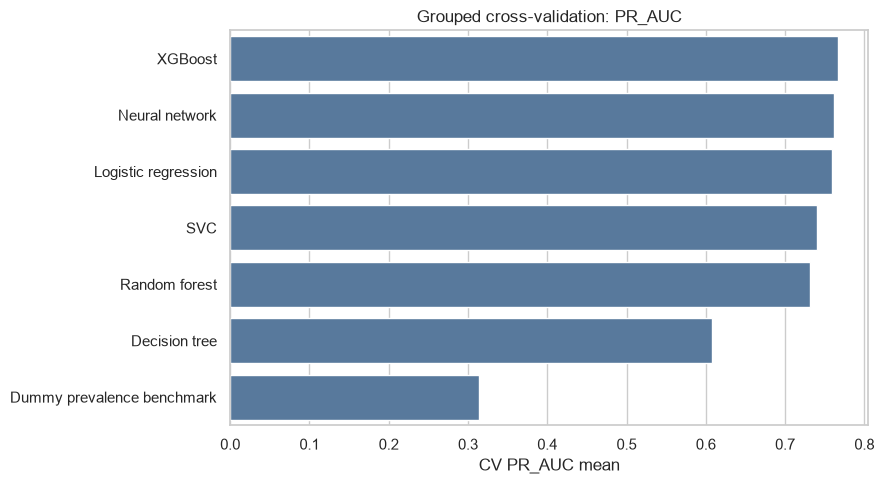

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=algorithm_results, x=sort_column, y="model", color="#4C78A8", ax=ax)
ax.set(title=f"Grouped cross-validation: {PRIMARY_METRIC}", ylabel="")
plt.tight_layout()

## 8. Compact tuning of the two leading algorithms

The two strongest non-dummy algorithms receive prespecified compact grids. Tuning uses development folds only and retains the same primary selection metric.

In [10]:
is_benchmark = algorithm_results["model"].str.contains("Dummy")
candidate_names = algorithm_results.loc[~is_benchmark, "model"].head(2).tolist()
parameter_grids = classification_parameter_grids() if TASK == "classification" else regression_parameter_grids()
tuning_rows = []
tuned_searches = {}
for model_name in candidate_names:
    search = GridSearchCV(
        build_supervised_pipeline(models[model_name], X_development, missing_strategy="missing_aware"),
        parameter_grids[model_name], scoring=SCORING, refit=PRIMARY_METRIC,
        cv=cv_splits, n_jobs=1, error_score="raise", return_train_score=False,
    )
    started = time.perf_counter()
    search.fit(X_development, y_development)
    tuned_searches[model_name] = search
    idx = search.best_index_
    row = {"model": model_name, "best parameters": search.best_params_, "runtime seconds": time.perf_counter() - started}
    for metric in SCORING:
        value = search.cv_results_[f"mean_test_{metric}"][idx]
        row[f"tuned CV {metric}"] = -value if metric in {"MAE", "RMSE", "Brier"} else value
    tuning_rows.append(row)
tuning_results = pd.DataFrame(tuning_rows).sort_values(
    f"tuned CV {PRIMARY_METRIC}", ascending=not HIGHER_IS_BETTER, ignore_index=True
)
best_model_name = tuning_results.iloc[0]["model"]
best_model = tuned_searches[best_model_name].best_estimator_
tuning_results

,model,best parameters,runtime seconds,tuned CV PR_AUC,tuned CV ROC_AUC,tuned CV Balanced_accuracy,tuned CV F1,tuned CV Recall,tuned CV Precision,tuned CV Brier
0,XGBoost,"{'model__learning_rate': 0.08, 'model__max_dep...",11.781923,0.776365,0.876327,0.800232,0.716254,0.794305,0.652243,0.140021
1,Neural network,"{'model__alpha': 0.0001, 'model__hidden_layer_...",71.002972,0.763325,0.864670,0.761334,0.674356,0.635413,0.724840,0.134154


## 9. Frozen final test evaluation

After missingness, features, algorithm and hyperparameters are selected, the winning model is evaluated on the untouched test set. Classification selects its provisional decision threshold from development out-of-fold probabilities, never from test outcomes.

In [11]:
if TASK == "classification":
    development_probability = cross_val_predict(
        clone(best_model), X_development, y_development, cv=cv_splits,
        method="predict_proba", n_jobs=1,
    )[:, 1]
    threshold_rows = []
    for threshold in np.linspace(0.10, 0.90, 81):
        predicted = (development_probability >= threshold).astype(int)
        threshold_rows.append({
            "threshold": threshold,
            "precision": precision_score(y_development, predicted, zero_division=0),
            "recall": recall_score(y_development, predicted, zero_division=0),
            "F1": f1_score(y_development, predicted, zero_division=0),
        })
    threshold_results = pd.DataFrame(threshold_rows)
    selected_threshold = threshold_results.sort_values(["F1", "recall"], ascending=False).iloc[0]["threshold"]
else:
    threshold_results = pd.DataFrame()
    selected_threshold = np.nan

best_model.fit(X_development, y_development)
if TASK == "classification":
    test_probability = best_model.predict_proba(X_test)[:, 1]
    test_prediction = (test_probability >= selected_threshold).astype(int)
    final_test_results = pd.DataFrame([{
        "model": best_model_name, "threshold": selected_threshold,
        "accuracy": accuracy_score(y_test, test_prediction),
        "balanced accuracy": balanced_accuracy_score(y_test, test_prediction),
        "ROC-AUC": roc_auc_score(y_test, test_probability),
        "PR-AUC": average_precision_score(y_test, test_probability),
        "precision": precision_score(y_test, test_prediction, zero_division=0),
        "recall": recall_score(y_test, test_prediction, zero_division=0),
        "F1": f1_score(y_test, test_prediction, zero_division=0),
        "Brier": brier_score_loss(y_test, test_probability),
    }])
else:
    test_prediction = best_model.predict(X_test)
    residual = y_test.to_numpy() - test_prediction
    final_test_results = pd.DataFrame([{
        "model": best_model_name,
        "MAE": mean_absolute_error(y_test, test_prediction),
        "RMSE": mean_squared_error(y_test, test_prediction) ** 0.5,
        "R2": r2_score(y_test, test_prediction),
        "within 10 minutes": np.mean(np.abs(residual) <= 10),
        "within 20 minutes": np.mean(np.abs(residual) <= 20),
        "within 30 minutes": np.mean(np.abs(residual) <= 30),
        "within 60 minutes": np.mean(np.abs(residual) <= 60),
    }])
final_test_results

,model,threshold,accuracy,balanced accuracy,ROC-AUC,PR-AUC,precision,recall,F1,Brier
0,XGBoost,0.54,0.810718,0.801741,0.886866,0.797195,0.671078,0.777656,0.720446,0.134915


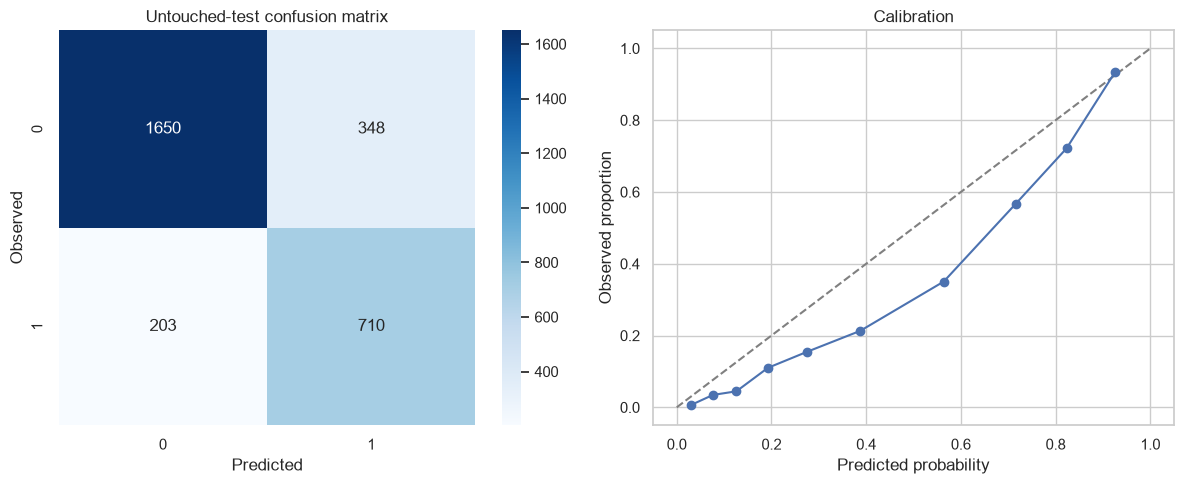

In [12]:
if TASK == "classification":
    matrix = confusion_matrix(y_test, test_prediction)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set(xlabel="Predicted", ylabel="Observed", title="Untouched-test confusion matrix")
    calibration = pd.DataFrame({"observed": y_test.to_numpy(), "probability": test_probability})
    calibration["bin"] = pd.qcut(calibration["probability"], q=10, duplicates="drop")
    calibration_plot = calibration.groupby("bin", observed=True).agg(
        predicted_probability=("probability", "mean"), observed_rate=("observed", "mean")
    ).reset_index()
    axes[1].plot([0, 1], [0, 1], "--", color="grey")
    axes[1].plot(calibration_plot["predicted_probability"], calibration_plot["observed_rate"], marker="o")
    axes[1].set(xlabel="Predicted probability", ylabel="Observed proportion", title="Calibration")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    residual = y_test.to_numpy() - test_prediction
    axes[0].scatter(y_test, test_prediction, alpha=0.25, s=16)
    bounds = [min(y_test.min(), test_prediction.min()), max(y_test.max(), test_prediction.max())]
    axes[0].plot(bounds, bounds, "--", color="grey")
    axes[0].set(xlabel="Observed", ylabel="Predicted", title="Observed versus predicted")
    axes[1].scatter(test_prediction, residual, alpha=0.25, s=16)
    axes[1].axhline(0, linestyle="--", color="grey")
    axes[1].set(xlabel="Predicted", ylabel="Observed - predicted", title="Residuals")
plt.tight_layout()

## 10. Operational benchmarks

Regression includes the dummy benchmark. Direct operation-length modelling additionally compares the hospital's `ExpectedDurationMins`. Duration-error modelling converts its predicted correction back to an operation-length prediction where the hospital plan is observed.

In [13]:
benchmark_results = pd.DataFrame()
if TASK == "regression":
    dummy = build_supervised_pipeline(regression_models()["Dummy median benchmark"], X_development, missing_strategy="missing_aware")
    dummy.fit(X_development, y_development)
    dummy_prediction = dummy.predict(X_test)
    rows = [{
        "benchmark": "Dummy median", "MAE": mean_absolute_error(y_test, dummy_prediction),
        "RMSE": mean_squared_error(y_test, dummy_prediction) ** 0.5,
        "R2": r2_score(y_test, dummy_prediction),
    }]
    expected = X_test_all.loc[y_test.index, "ExpectedDurationMins"]
    available = expected.notna()
    if TARGET == "operation_length_mins":
        rows.append({
            "benchmark": "Hospital ExpectedDurationMins",
            "MAE": mean_absolute_error(y_test.loc[available], expected.loc[available]),
            "RMSE": mean_squared_error(y_test.loc[available], expected.loc[available]) ** 0.5,
            "R2": r2_score(y_test.loc[available], expected.loc[available]),
        })
    elif TARGET == "duration_error_mins":
        actual_duration = y_test.loc[available] + expected.loc[available]
        corrected_duration = test_prediction[available.to_numpy()] + expected.loc[available].to_numpy()
        rows.append({
            "benchmark": "Error-corrected operation length",
            "MAE": mean_absolute_error(actual_duration, corrected_duration),
            "RMSE": mean_squared_error(actual_duration, corrected_duration) ** 0.5,
            "R2": r2_score(actual_duration, corrected_duration),
        })
    benchmark_results = pd.DataFrame(rows)
benchmark_results

""


## 11. Prespecified sensitivity analyses

The final specification is refitted with provisional start hour, without flagged records, and on complete cases. These results assess stability; they do not replace the primary test result or reopen model selection.

In [14]:
def compact_metrics(actual, prediction, probability=None):
    if TASK == "classification":
        return {
            "PR-AUC": average_precision_score(actual, probability),
            "ROC-AUC": roc_auc_score(actual, probability),
            "F1": f1_score(actual, prediction, zero_division=0),
            "recall": recall_score(actual, prediction, zero_division=0),
        }
    return {
        "MAE": mean_absolute_error(actual, prediction),
        "RMSE": mean_squared_error(actual, prediction) ** 0.5,
        "R2": r2_score(actual, prediction),
    }

sensitivity_rows = [{"analysis": "Primary", "development rows": len(y_development), "test rows": len(y_test), **compact_metrics(y_test, test_prediction, test_probability if TASK == "classification" else None)}]

# Provisional start hour.
start_columns = selected_columns + [START_HOUR_COLUMN]
start_model = build_supervised_pipeline(clone(best_model.named_steps["model"]), X_development_all[start_columns], missing_strategy="missing_aware")
start_model.fit(X_development_all[start_columns], y_development)
if TASK == "classification":
    start_probability = start_model.predict_proba(X_test_all[start_columns])[:, 1]
    start_prediction = (start_probability >= selected_threshold).astype(int)
else:
    start_probability = None
    start_prediction = start_model.predict(X_test_all[start_columns])
sensitivity_rows.append({"analysis": "Start hour included", "development rows": len(y_development), "test rows": len(y_test), **compact_metrics(y_test, start_prediction, start_probability)})

# Duration-review records excluded.
keep_development = ~review_development.to_numpy()
keep_test = ~review_test.to_numpy()
flag_model = clone(best_model)
flag_model.fit(X_development.iloc[keep_development], y_development.iloc[keep_development])
if TASK == "classification":
    flag_probability = flag_model.predict_proba(X_test.iloc[keep_test])[:, 1]
    flag_prediction = (flag_probability >= selected_threshold).astype(int)
else:
    flag_probability = None
    flag_prediction = flag_model.predict(X_test.iloc[keep_test])
sensitivity_rows.append({
    "analysis": "Flagged records excluded", "development rows": int(keep_development.sum()),
    "test rows": int(keep_test.sum()),
    **compact_metrics(y_test.iloc[keep_test], flag_prediction, flag_probability),
})

# Complete cases.
complete_development = X_development.notna().all(axis=1)
complete_test = X_test.notna().all(axis=1)
complete_model = build_supervised_pipeline(
    clone(best_model.named_steps["model"]), X_development.loc[complete_development], missing_strategy="complete_case"
)
complete_model.fit(X_development.loc[complete_development], y_development.loc[complete_development])
if TASK == "classification":
    complete_probability = complete_model.predict_proba(X_test.loc[complete_test])[:, 1]
    complete_prediction = (complete_probability >= selected_threshold).astype(int)
else:
    complete_probability = None
    complete_prediction = complete_model.predict(X_test.loc[complete_test])
sensitivity_rows.append({
    "analysis": "Complete cases", "development rows": int(complete_development.sum()),
    "test rows": int(complete_test.sum()),
    **compact_metrics(y_test.loc[complete_test], complete_prediction, complete_probability),
})
sensitivity_results = pd.DataFrame(sensitivity_rows)
sensitivity_results

,analysis,development rows,test rows,PR-AUC,ROC-AUC,F1,recall
0,Primary,11647,2911,0.797195,0.886866,0.720446,0.777656
1,Start hour included,11647,2911,0.800842,0.890014,0.732006,0.785323
2,Flagged records excluded,11635,2911,0.793856,0.885309,0.727180,0.780942
3,Complete cases,4490,1143,0.432414,0.785886,0.405405,0.379747


In [15]:
primary_row = sensitivity_results.set_index("analysis").loc["Primary"]
start_row = sensitivity_results.set_index("analysis").loc["Start hour included"]
if TASK == "classification":
    start_hour_interpretation = (
        "Adding provisional operation_start_hour changed PR-AUC from "
        f"{primary_row['PR-AUC']:.3f} to {start_row['PR-AUC']:.3f} "
        f"and recall from {primary_row['recall']:.3f} to {start_row['recall']:.3f}. "
        "Because start hour was reconstructed rather than directly validated from the "
        "operational source system, it is reported as sensitivity-only and is not adopted "
        "as a primary predictor."
    )
else:
    start_hour_interpretation = (
        "Adding provisional operation_start_hour changed MAE from "
        f"{primary_row['MAE']:.2f} to {start_row['MAE']:.2f} minutes "
        f"and R2 from {primary_row['R2']:.3f} to {start_row['R2']:.3f}. "
        "Because start hour was reconstructed rather than directly validated from the "
        "operational source system, it is reported as sensitivity-only and is not adopted "
        "as a primary predictor."
    )
print(start_hour_interpretation)

Adding provisional operation_start_hour changed PR-AUC from 0.797 to 0.801 and recall from 0.778 to 0.785. Because start hour was reconstructed rather than directly validated from the operational source system, it is reported as sensitivity-only and is not adopted as a primary predictor.


## 12. Model interpretation

Permutation importance measures the reduction in untouched-test performance when one original column is shuffled. It explains any winning model, including a neural network, without relying on its internal structure. Supporting Decision Tree, Random Forest and XGBoost importances are aggregated from one-hot levels back to original columns.

,feature,importance mean,importance SD,rank
0,ExpectedDurationMins,0.182147,0.008688,1
1,anaesthetic_desc,0.073666,0.006651,2
2,procedure_code_group,0.071464,0.005716,3
3,intended_management_label,0.050249,0.005724,4
4,procedure_code_category,0.049562,0.005480,5
5,admission_type_label,0.038276,0.004607,6
6,ASAScore,0.011864,0.002281,7
7,priority_level_label,0.009972,0.002501,8
8,age_at_operation,0.007695,0.002179,9
9,sex_national_code,-0.000655,0.000939,10


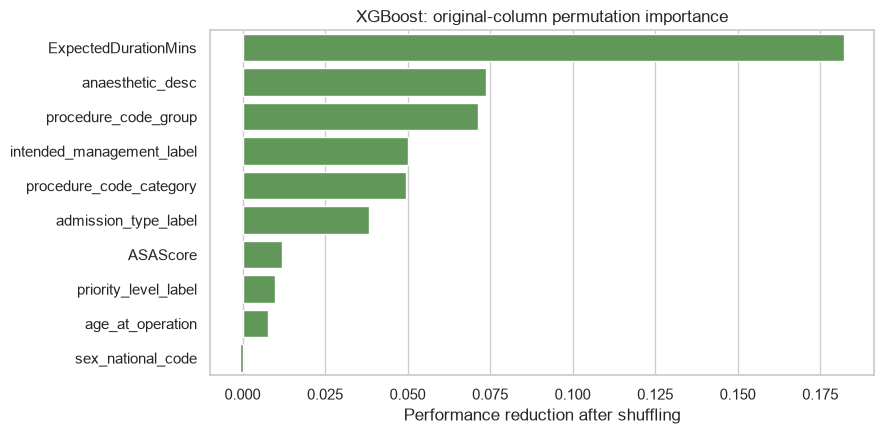

In [16]:
importance_scoring = "average_precision" if TASK == "classification" else "neg_mean_absolute_error"
permutation = permutation_importance(
    best_model, X_test, y_test, scoring=importance_scoring,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=1,
)
permutation_importance_results = pd.DataFrame({
    "feature": selected_columns,
    "importance mean": permutation.importances_mean,
    "importance SD": permutation.importances_std,
}).sort_values("importance mean", ascending=False, ignore_index=True)
permutation_importance_results["rank"] = np.arange(1, len(permutation_importance_results) + 1)

tree_importance_frames = []
for tree_name in ["Decision tree", "Random forest", "XGBoost"]:
    if tree_name == best_model_name:
        fitted_tree = best_model
    else:
        fitted_tree = build_supervised_pipeline(
            clone(models[tree_name]), X_development, missing_strategy="missing_aware"
        ).fit(X_development, y_development)
    aggregated = aggregate_tree_importance(fitted_tree, selected_columns)
    aggregated.insert(0, "model", tree_name)
    tree_importance_frames.append(aggregated)
tree_importance_results = pd.concat(tree_importance_frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(permutation_importance_results))))
sns.barplot(
    data=permutation_importance_results,
    x="importance mean", y="feature", color="#59A14F", ax=ax,
)
ax.set(title=f"{best_model_name}: original-column permutation importance", xlabel="Performance reduction after shuffling", ylabel="")
plt.tight_layout()
permutation_importance_results

Permutation and tree importance are predictive, not causal. Correlated columns can divide importance between themselves, and missingness patterns may contribute to predictions. These results explain the frozen model and are not used to reopen feature or model selection.

## 13. Export reproducible evidence

Only result tables and index-linked predictions are exported. No duplicate cleaned datasets are created.

In [17]:
RESULT_DIR = PROJECT_ROOT / "result" / "modeling" / TARGET
RESULT_DIR.mkdir(parents=True, exist_ok=True)
tables = {
    "population_audit": population_audit,
    "missingness_audit": missingness_audit,
    "split_audit": split_audit,
    "missing_strategy_comparison": missing_strategy_results,
    "feature_configuration_comparison": feature_results,
    "algorithm_comparison": algorithm_results,
    "tuning_results": tuning_results.assign(**{"best parameters": tuning_results["best parameters"].astype(str)}),
    "final_test_metrics": final_test_results,
    "sensitivity_results": sensitivity_results,
    "permutation_importance": permutation_importance_results,
    "tree_importance": tree_importance_results,
}
if not benchmark_results.empty:
    tables["operational_benchmarks"] = benchmark_results
if not threshold_results.empty:
    tables["threshold_comparison"] = threshold_results
for name, table in tables.items():
    table.to_csv(RESULT_DIR / f"{name}.csv", index=False)

predictions = pd.DataFrame({"source_index": y_test.index, "observed": y_test.to_numpy(), "predicted": test_prediction})
if TASK == "classification":
    predictions["predicted_probability"] = test_probability
predictions.to_csv(RESULT_DIR / "test_predictions.csv", index=False)

selection_summary = pd.DataFrame({
    "selection": ["target", "missing strategy", "feature configuration", "model", "threshold"],
    "value": [TARGET, selected_missing_strategy, selected_feature_name, best_model_name, selected_threshold],
})
selection_summary.to_csv(RESULT_DIR / "selection_summary.csv", index=False)
selection_summary

,selection,value
0,target,meaningful_overrun_flag
1,missing strategy,"Missing-aware, priority retained"
2,feature configuration,Both procedure levels
3,model,XGBoost
4,threshold,0.54


## 14. Interpretation boundaries

- Configuration and algorithm selection are internal-validation results, not evidence of causal effects.
- The test result estimates performance only for this dataset and requires temporal or external validation.
- Missing-aware preprocessing preserves cases but may learn from recording patterns; complete-case results describe a smaller population.
- Start hour is provisional and cannot become a primary predictor until its reconstruction is validated.
- Flagged-record sensitivity may be imprecise because only 12 records are flagged.
- Operational thresholds require stakeholder input about the relative cost of missed overruns and false warnings.